# Convolutional Neural Networks with Keras

In this lab, we will learn how to use the Keras library to build convolutional neural networks. We will also use the popular MNIST dataset and we will compare our results to using a conventional neural network.

In [1]:
# Import Keras and Packages

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

In [2]:
# Additional packages for CNN

from keras.layers import Conv2D # to add convolutional layers
from keras.layers import Activation # to add activation function
from keras.layers import MaxPooling2D # to add pooling layers
from keras.layers import Flatten # to flatten data for fully connected layers

### Convolutional Neural Network with One Set of Convolutional and Pooling Layers

In [3]:
# import data
from keras.datasets import mnist

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train original shape:", X_train.shape)
print("y_train original shape:", y_train.shape)
print("X_test original shape:", X_test.shape)
print("y_test original shape:", y_test.shape)

X_train original shape: (60000, 28, 28)
y_train original shape: (60000,)
X_test original shape: (10000, 28, 28)
y_test original shape: (10000,)


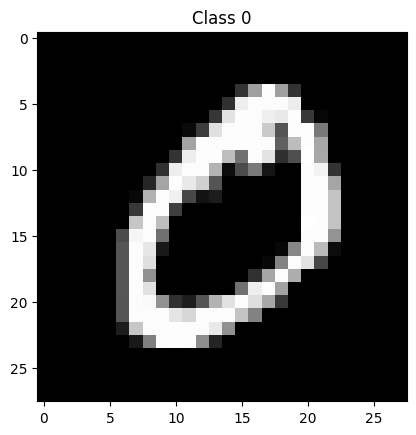

In [10]:
# Plot a grayscale image with the label
import matplotlib.pyplot as plt

plt.imshow(X_train[1], cmap='gray')
plt.title('Class ' + str(y_train[1]))
plt.show()

In [5]:
# reshape to be [batch][height][width][channel]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

In [6]:
# Normalize inputs from 0-255 to 0-1
X_train = X_train / 255 # normalize training data
X_test = X_test / 255 # normalize test data

**Prepare Validation Set**

Split training data into training (80%) and validation (20%)

`stratify=y_train`ensures that both the training and validation sets have approximately the same percentage of each digit.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)             

In [12]:
# one hot encode outputs to convert the target variable into binary categories
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1] # number of categories
print(num_classes)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

10
X_train shape: (48000, 28, 28, 1)
y_train shape: (48000, 10)
X_val shape: (12000, 28, 28, 1)
y_val shape: (12000, 10)
X_test shape: (10000, 28, 28, 1)
y_test shape: (10000, 10)


**Build CNN with one set of convolutional and pooling layers**

In [13]:
def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(100))
    model.add(Activation('relu'))
    model.add(Dense(num_classes))
    model.add(Activation('softmax'))
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

**Train and Test the Network**

In [18]:
# build the model
model = convolutional_model()

# fit the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=200, verbose=2)

Epoch 1/20
240/240 - 4s - 15ms/step - accuracy: 0.8367 - loss: 0.5704 - val_accuracy: 0.9424 - val_loss: 0.1948
Epoch 2/20
240/240 - 3s - 11ms/step - accuracy: 0.9572 - loss: 0.1466 - val_accuracy: 0.9660 - val_loss: 0.1160
Epoch 3/20
240/240 - 3s - 10ms/step - accuracy: 0.9685 - loss: 0.1016 - val_accuracy: 0.9708 - val_loss: 0.1012
Epoch 4/20
240/240 - 2s - 10ms/step - accuracy: 0.9755 - loss: 0.0794 - val_accuracy: 0.9762 - val_loss: 0.0740
Epoch 5/20
240/240 - 2s - 10ms/step - accuracy: 0.9789 - loss: 0.0680 - val_accuracy: 0.9812 - val_loss: 0.0638
Epoch 6/20
240/240 - 2s - 10ms/step - accuracy: 0.9818 - loss: 0.0582 - val_accuracy: 0.9772 - val_loss: 0.0725
Epoch 7/20
240/240 - 2s - 10ms/step - accuracy: 0.9836 - loss: 0.0526 - val_accuracy: 0.9793 - val_loss: 0.0650
Epoch 8/20
240/240 - 2s - 10ms/step - accuracy: 0.9861 - loss: 0.0468 - val_accuracy: 0.9837 - val_loss: 0.0533
Epoch 9/20
240/240 - 3s - 11ms/step - accuracy: 0.9871 - loss: 0.0423 - val_accuracy: 0.9832 - val_loss:

**Visualize the accuracy and loss for training and validation sets**

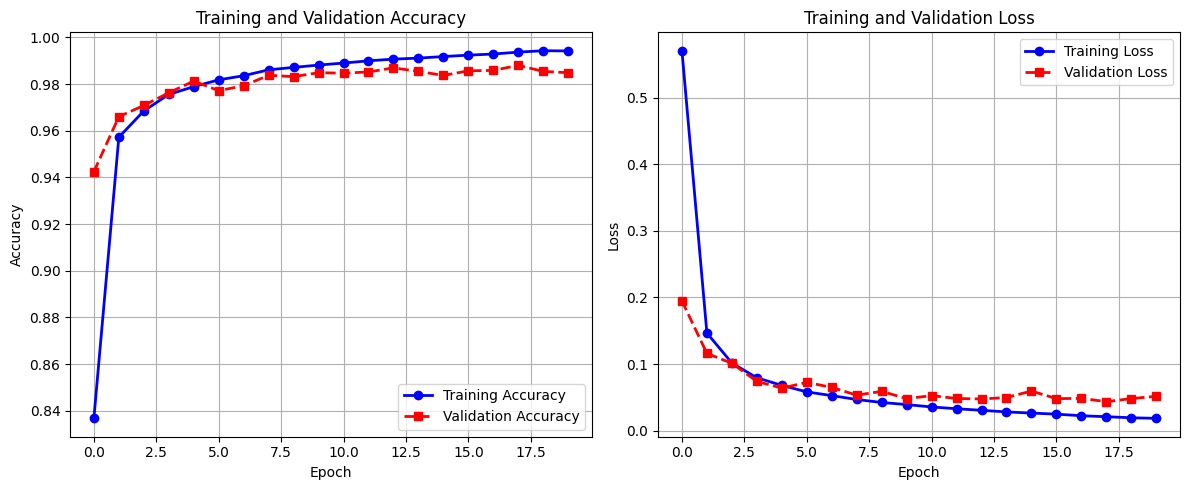

In [19]:
# Create a figure with two subplots
plt.figure(figsize=(12,5))

# ==========================
# Accuracy Curve
# ==========================
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],color='blue',marker='o',linewidth=2,label='Training Accuracy')
plt.plot(history.history['val_accuracy'],color='red',marker='s',linestyle='--',linewidth=2,label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(loc='lower right')    

# ==========================
# Loss Curve
# ==========================
plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='blue',marker='o',linewidth=2,label='Training Loss')
plt.plot(history.history['val_loss'],color='red',marker='s',linestyle='--',linewidth=2,label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)  
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()      

In [20]:
# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: {} \n Error: {}".format(scores[1], 1-scores[1]))

Accuracy: 0.9872999787330627 
 Error: 0.012700021266937256


In [ ]:
# Write your observation here: 

### Convolutional Neural Network with Two Sets of Convolutional and Pooling Layers

**Practice Exercise 1**

1. Create a Sequential model
2. Add the input layer
3. Add a convolution layer with: 16 filters, and filter size = (5,5)
4. Apply the ReLU activation function.
5. Reduce the feature map size using Max Pooling with: pool size = (2,2), stride = (2,2)
6. Add another convolution layer with: 8 filters, and filter size = (2,2)
7. Add another ReLU activation
8. Add the second pooling layer
9. Flatten the feature maps
10. Add a fully connected layer with 100 neurons.
11. Apply ReLU activation
12. Add the output layer
13. Apply Softmax activation
14. Train and evaluate the Modified CNN

In [17]:
# Write your answer here

def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(Conv2D(8, (2, 2), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
    
    model.add(Flatten())
    model.add(Dense(100))
    model.add(Activation('relu'))
    model.add(Dense(num_classes))
    model.add(Activation('softmax'))
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

**Practice Exercise 2**

Keep the batch_size=1024 and epochs=15 and check it's effect on accuracy

In [27]:
# Write your answer here

# build the model
model = convolutional_model()

# fit the model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=15, batch_size=1024, verbose=2)

Epoch 1/15
47/47 - 4s - 91ms/step - accuracy: 0.9008 - loss: 0.3317 - val_accuracy: 0.1462 - val_loss: 1.8675
Epoch 2/15
47/47 - 3s - 58ms/step - accuracy: 0.9776 - loss: 0.0833 - val_accuracy: 0.1183 - val_loss: 2.0792
Epoch 3/15
47/47 - 3s - 60ms/step - accuracy: 0.9872 - loss: 0.0513 - val_accuracy: 0.1482 - val_loss: 2.0558
Epoch 4/15
47/47 - 3s - 60ms/step - accuracy: 0.9920 - loss: 0.0350 - val_accuracy: 0.2017 - val_loss: 1.9206
Epoch 5/15
47/47 - 3s - 60ms/step - accuracy: 0.9953 - loss: 0.0241 - val_accuracy: 0.3230 - val_loss: 1.6202
Epoch 6/15
47/47 - 3s - 59ms/step - accuracy: 0.9976 - loss: 0.0169 - val_accuracy: 0.4555 - val_loss: 1.2956
Epoch 7/15
47/47 - 3s - 58ms/step - accuracy: 0.9987 - loss: 0.0123 - val_accuracy: 0.7184 - val_loss: 0.8278
Epoch 8/15
47/47 - 3s - 53ms/step - accuracy: 0.9994 - loss: 0.0087 - val_accuracy: 0.8636 - val_loss: 0.5052
Epoch 9/15
47/47 - 2s - 46ms/step - accuracy: 0.9998 - loss: 0.0064 - val_accuracy: 0.9396 - val_loss: 0.2746
Epoch 10/1

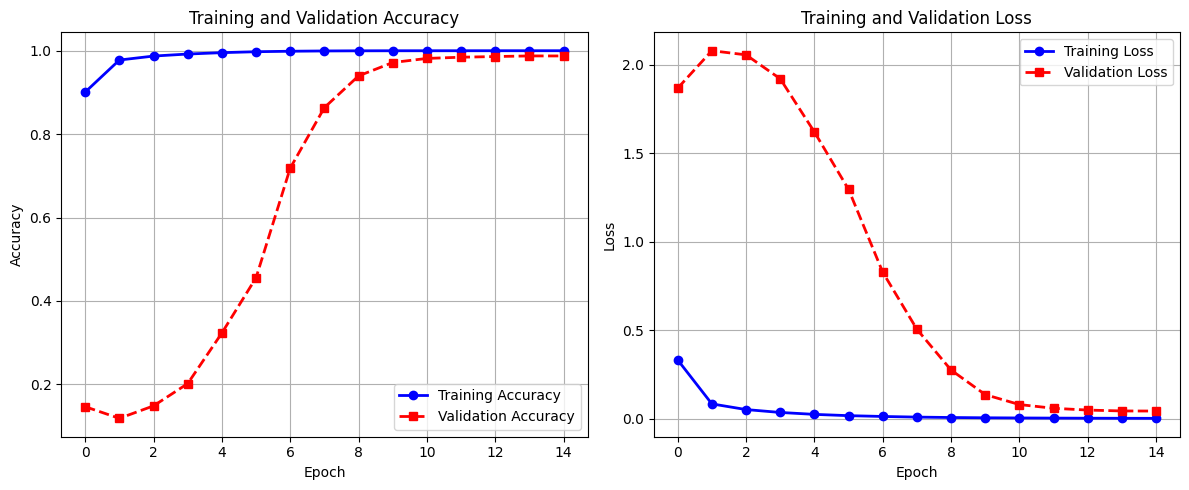

In [28]:
# Create a figure with two subplots
plt.figure(figsize=(12,5))

# ==========================
# Accuracy Curve
# ==========================
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],color='blue',marker='o',linewidth=2,label='Training Accuracy')
plt.plot(history.history['val_accuracy'],color='red',marker='s',linestyle='--',linewidth=2,label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(loc='lower right')    

# ==========================
# Loss Curve
# ==========================
plt.subplot(1,2,2)
plt.plot(history.history['loss'], color='blue',marker='o',linewidth=2,label='Training Loss')
plt.plot(history.history['val_loss'],color='red',marker='s',linestyle='--',linewidth=2,label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)  
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()      

# Modified CNN

## Practice Exercise: 
 
Observe the following techniques affects the training process and the model's ability to classify handwritten digits.

### Batch Normalization
- Normalize activations
- Faster convergence
- More stable training

**Practice Exercise 3**
1. Add the following import statement `from keras.layers import BatchNormalization`
2. Add Batch Normalization after the Convolutional Layer `model.add(BatchNormalization())`
3. Add Batch Normalization after the Hidden Dense Layer `model.add(BatchNormalization())`
4. Train and evaluate the Modified CNN

In [26]:
from keras.layers import BatchNormalization


def convolutional_model():
    
    # create model
    model = Sequential()
    model.add(Input(shape=(28, 28, 1)))
    model.add(Conv2D(16, (5, 5), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(BatchNormalization())
    
    model.add(Flatten())
    model.add(Dense(100))
    model.add(Activation('relu'))
    model.add(BatchNormalization())
    model.add(Dense(num_classes))
    model.add(Activation('softmax'))
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

In [ ]:
#Type your answer here

### Dropout
- Reduce overfitting
- Improve generalization

**Practice Exercise 4**
1. Add the following import statement `from keras.layers import Dropout`
2. Add a Dropout layer `model.add(Dropout(0.3))` after the ReLU activation function in the dense neural network
3. Train and evaluate the Modified CNN

In [ ]:
#Type your answer here